In [ ]:
!pip install catboost
!pip install shap
!pip install lime
!pip install pdpbox

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# SMOTE
from imblearn.over_sampling import SMOTE

# CatBoost
from catboost import CatBoostClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Explainability
import shap

from lime.lime_tabular import LimeTabularExplainer

from sklearn.inspection import PartialDependenceDisplay

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/diabetes_binary_health_indicators_BRFSS2015 (1).csv")

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Selected Features

In [ ]:
selected_features = [
    'GenHlth',
    'HighBP',
    'BMI',
    'DiffWalk',
    'HighChol',
    'Age',
    'HeartDiseaseorAttack',
    'PhysHlth',
    'MentHlth',
    'Income'
]

In [ ]:
X = df[selected_features]

y = df["Diabetes_binary"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

SMOTE

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:", y_train.value_counts())

print("After SMOTE:", pd.Series(y_train_resampled).value_counts())

Before SMOTE: Diabetes_binary
0.0    174667
1.0     28277
Name: count, dtype: int64
After SMOTE: Diabetes_binary
0.0    174667
1.0    174667
Name: count, dtype: int64




# CatBoost Model

In [ ]:
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_state=42,
    verbose=100
)

In [ ]:
#Train Model
cat_model.fit(
    X_train_resampled,
    y_train_resampled
)


0:	total: 392ms	remaining: 1m 57s
100:	total: 22.5s	remaining: 44.3s
200:	total: 34.6s	remaining: 17s
299:	total: 42.9s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=100)

In [ ]:
y_pred = cat_model.predict(X_test_scaled)

y_prob = cat_model.predict_proba(X_test_scaled)[:,1]

**Evaluation**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)

print("AUC:", auc)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 0.8498896247240618
AUC: 0.8133874870970378

Classification Report:

              precision    recall  f1-score   support

         0.0       0.89      0.94      0.91     43667
         1.0       0.44      0.31      0.37      7069

    accuracy                           0.85     50736
   macro avg       0.67      0.62      0.64     50736
weighted avg       0.83      0.85      0.84     50736



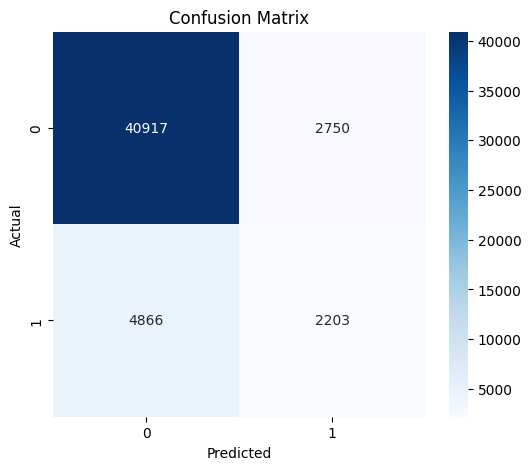

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

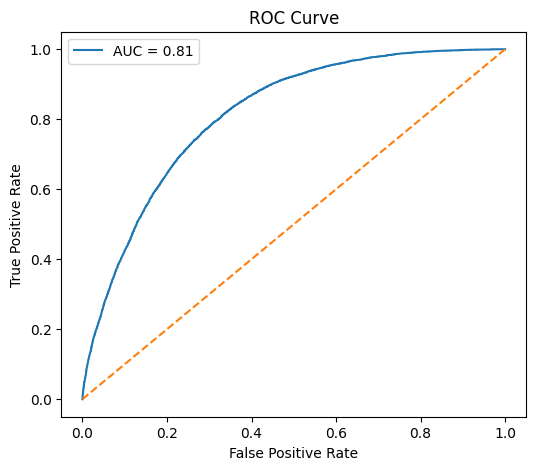

In [ ]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# Explainability

Feature Importance

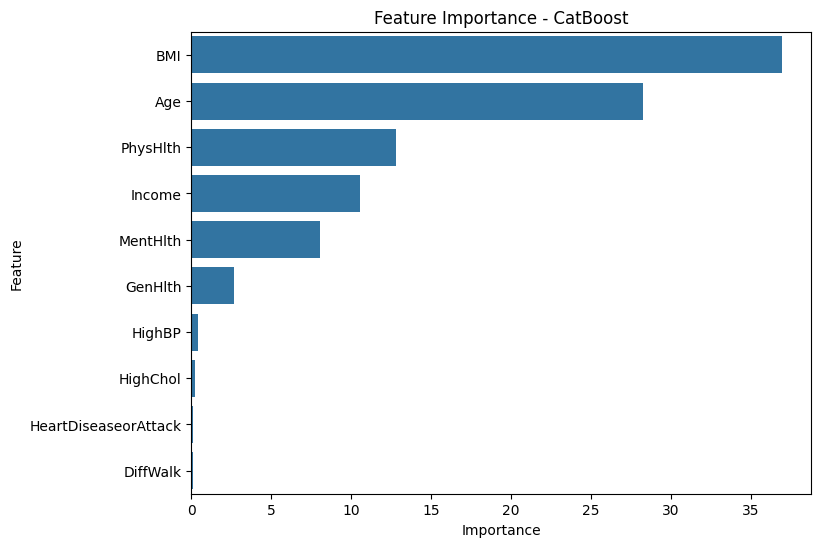

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': cat_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance - CatBoost")

plt.show()

SHAP

In [ ]:
explainer = shap.TreeExplainer(cat_model)

shap_values = explainer.shap_values(X_test_scaled[:1000])

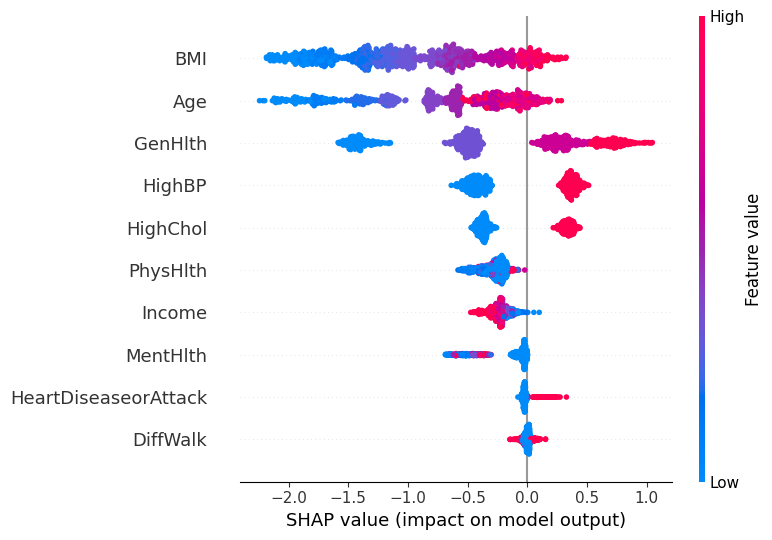

In [ ]:
shap.summary_plot(
    shap_values,
    X_test.iloc[:1000],
    feature_names=selected_features
)

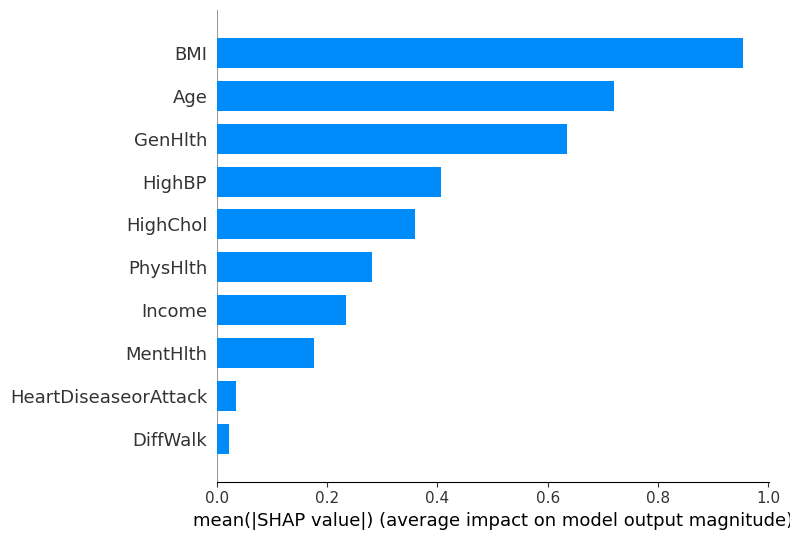

In [ ]:
shap.summary_plot(
    shap_values,
    X_test.iloc[:1000],
    feature_names=selected_features,
    plot_type="bar"
)

SHAP Dependence Plot

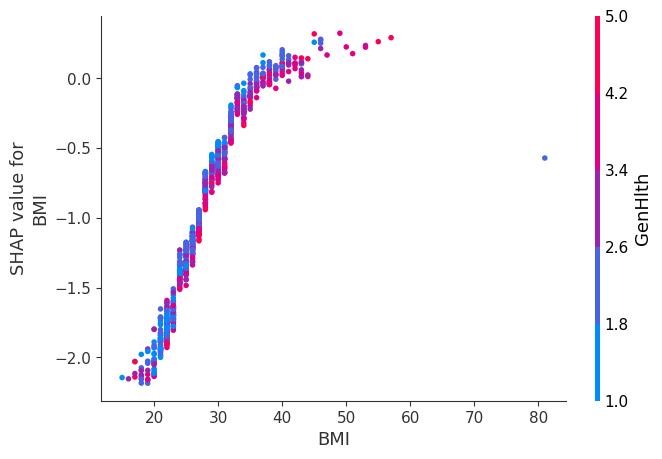

In [ ]:
shap.dependence_plot(
    "BMI",
    shap_values,
    X_test.iloc[:1000],
    feature_names=selected_features
)

LIME

In [ ]:
explainer_lime = LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=selected_features,
    class_names=['Non-Diabetic', 'Diabetic'],
    mode='classification'
)

In [ ]:
#Explain One Instance
exp = explainer_lime.explain_instance(
    X_test_scaled[0],
    cat_model.predict_proba,
    num_features=10
)

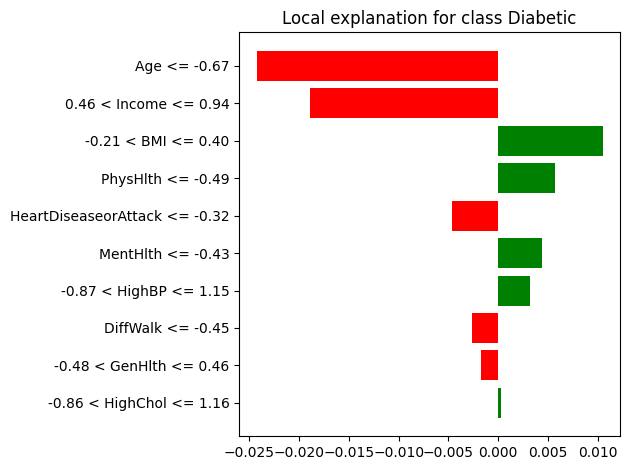

In [ ]:
fig = exp.as_pyplot_figure()

plt.tight_layout()

plt.show()

# ICE

In [ ]:
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=selected_features
)

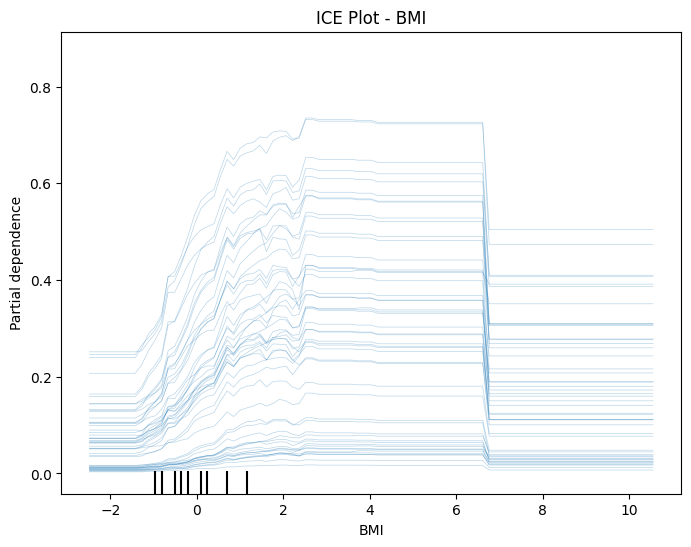

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

features_to_plot = ["BMI"]

fig, ax = plt.subplots(figsize=(8,6))

PartialDependenceDisplay.from_estimator(
    cat_model,
    X_test_scaled_df,
    features=features_to_plot,
    kind="individual",
    subsample=50,
    random_state=42,
    ax=ax
)

plt.title("ICE Plot - BMI")

plt.show()